## MDP

We use Markov's idea for decision making in an stochastic environment, We have an environment that making decisions in it is probabilistic.<br>

An MDP is defined by:
+ A set of **states** $s \in S$
+ A set of **actions** $a \in A$
    > When we decide to take an action in a space, it does not happen necessarily and thus we have a transition model.
+ A **transition model** $T(s, a, s')$: It is the probability that $a$ from $s$ leads to $s'$, i.e., $P(s'|s, a)$
+ A **reward function** $R(s, a, s')$ for each transition: It's the function that we should go through which path.
+ A **start state**.
+ Possibly a **terminal state** (or absorbing state)
+ **Utility** funciton which is additive (discounted) rewards

> Our purpose is to find a policy or a path with the maximum utility.

> The reward we get at a single moment is not that much important, The thing that has the most importance in the end is the utility value.

Our model is completely **observable** but with **probabilistic** search problems.

### Policy

The function that do the decision making here, we call it **policy**. It is based on this function that we do decision making. 

+ A policy $\pi$ gives an action for each state: $\pi: S \rightarrow A$. (Plicy function's input is an state and it's output is an action).

+ In **deterministic** (not stochastic) single-agent search problems, we wanted an optimal `plan`, or sequence of actions, from start to a goal.

+ For MDPs, we want an optimal `policy`: $\pi^*: S \rightarrow A$

What is the **optimal policy**?
+ It's the policy that gives me the maximum reward in the long run.

**Sample Optimal Policies**:
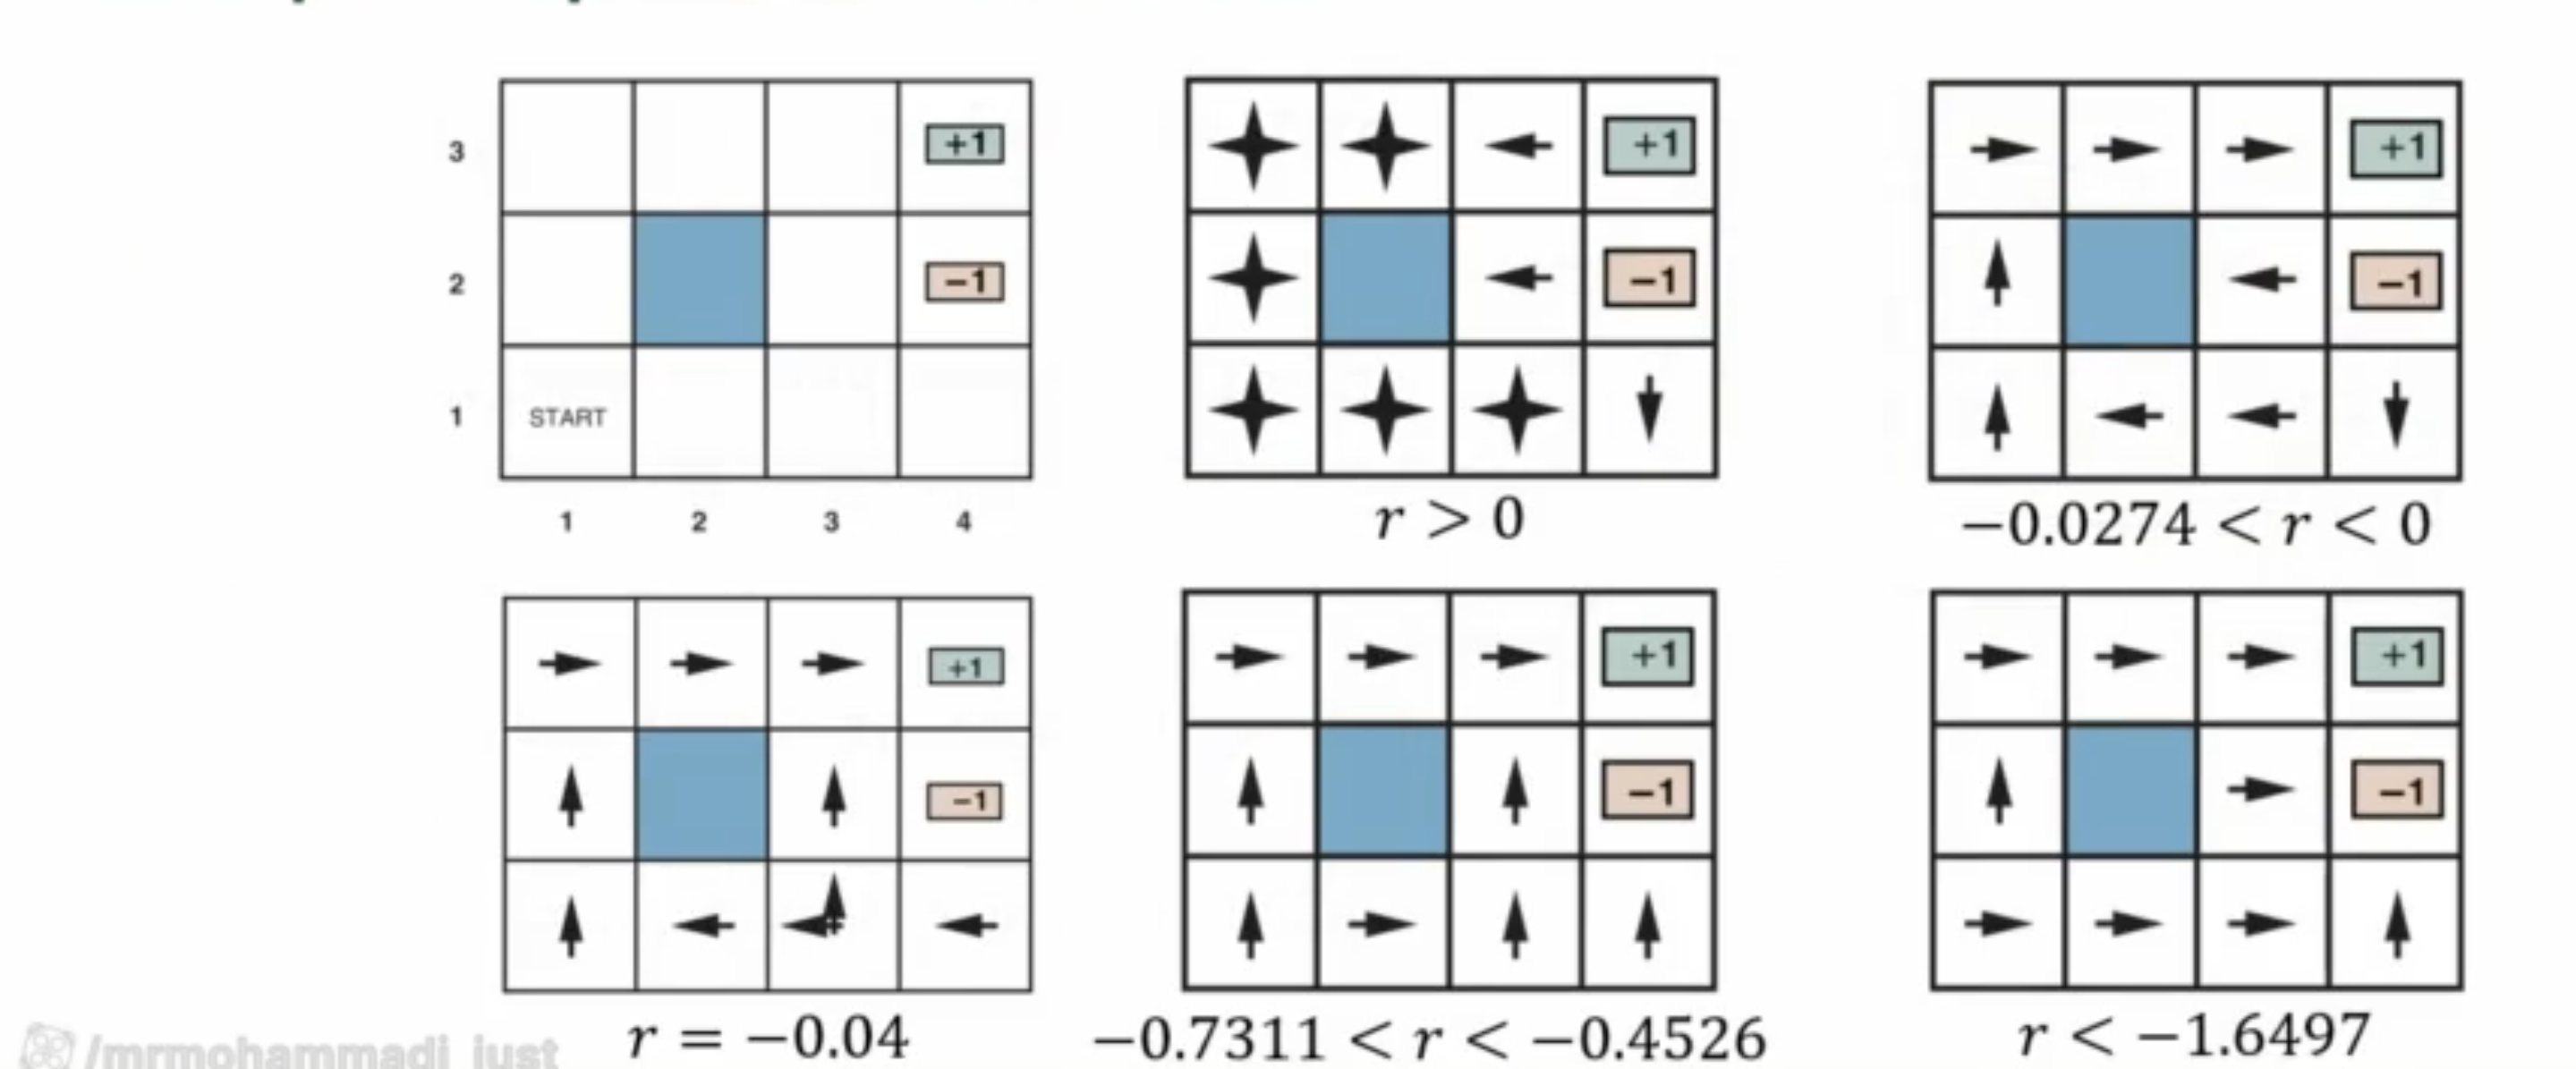
<center>Figure 1: Sample Optimal Policies, Adopted from [1]</center>
<br>

> In the figure above $r$ is the reward of each action/state.

We want our agent to start from the `start` state an obtain the maximum reward.

+ If $r > 0$ be positive, It always tries not to enter the terminal state, because it says that if I move I get good reward so what's the point in stopping in a state. (And because of this $r$ is usually negative).
+ If we put a small negative for $r$ like in the top right scenario, it only does **safe** movements(i.e., if it be close to -1 it says to go left, and if there was slightest chance the action changes it does not go to the -1 cell.)
+ If we increase the negativity of $r$ a little bit it **takes a little chance** and make the time to reach to the terminal state a bit less.(like in the down left scenario that when it is beside the -1 cell it chooses to go up and have a slight chance that this action goes wrong and the agent move to the -1 cell but the thing we got from this was the speed of reaching to the +1 cell)
+ And we see that if the reward be a big negative value, it is possible that it prefers the -1 cell instead of doing an action and get a very negative (smaller than -1) reward, cause it collects the maximum reward at the end.

Now how do we calculate?

Example:

In the example below we have 3 states and only two actions. And the below figure is it's **transition model**:

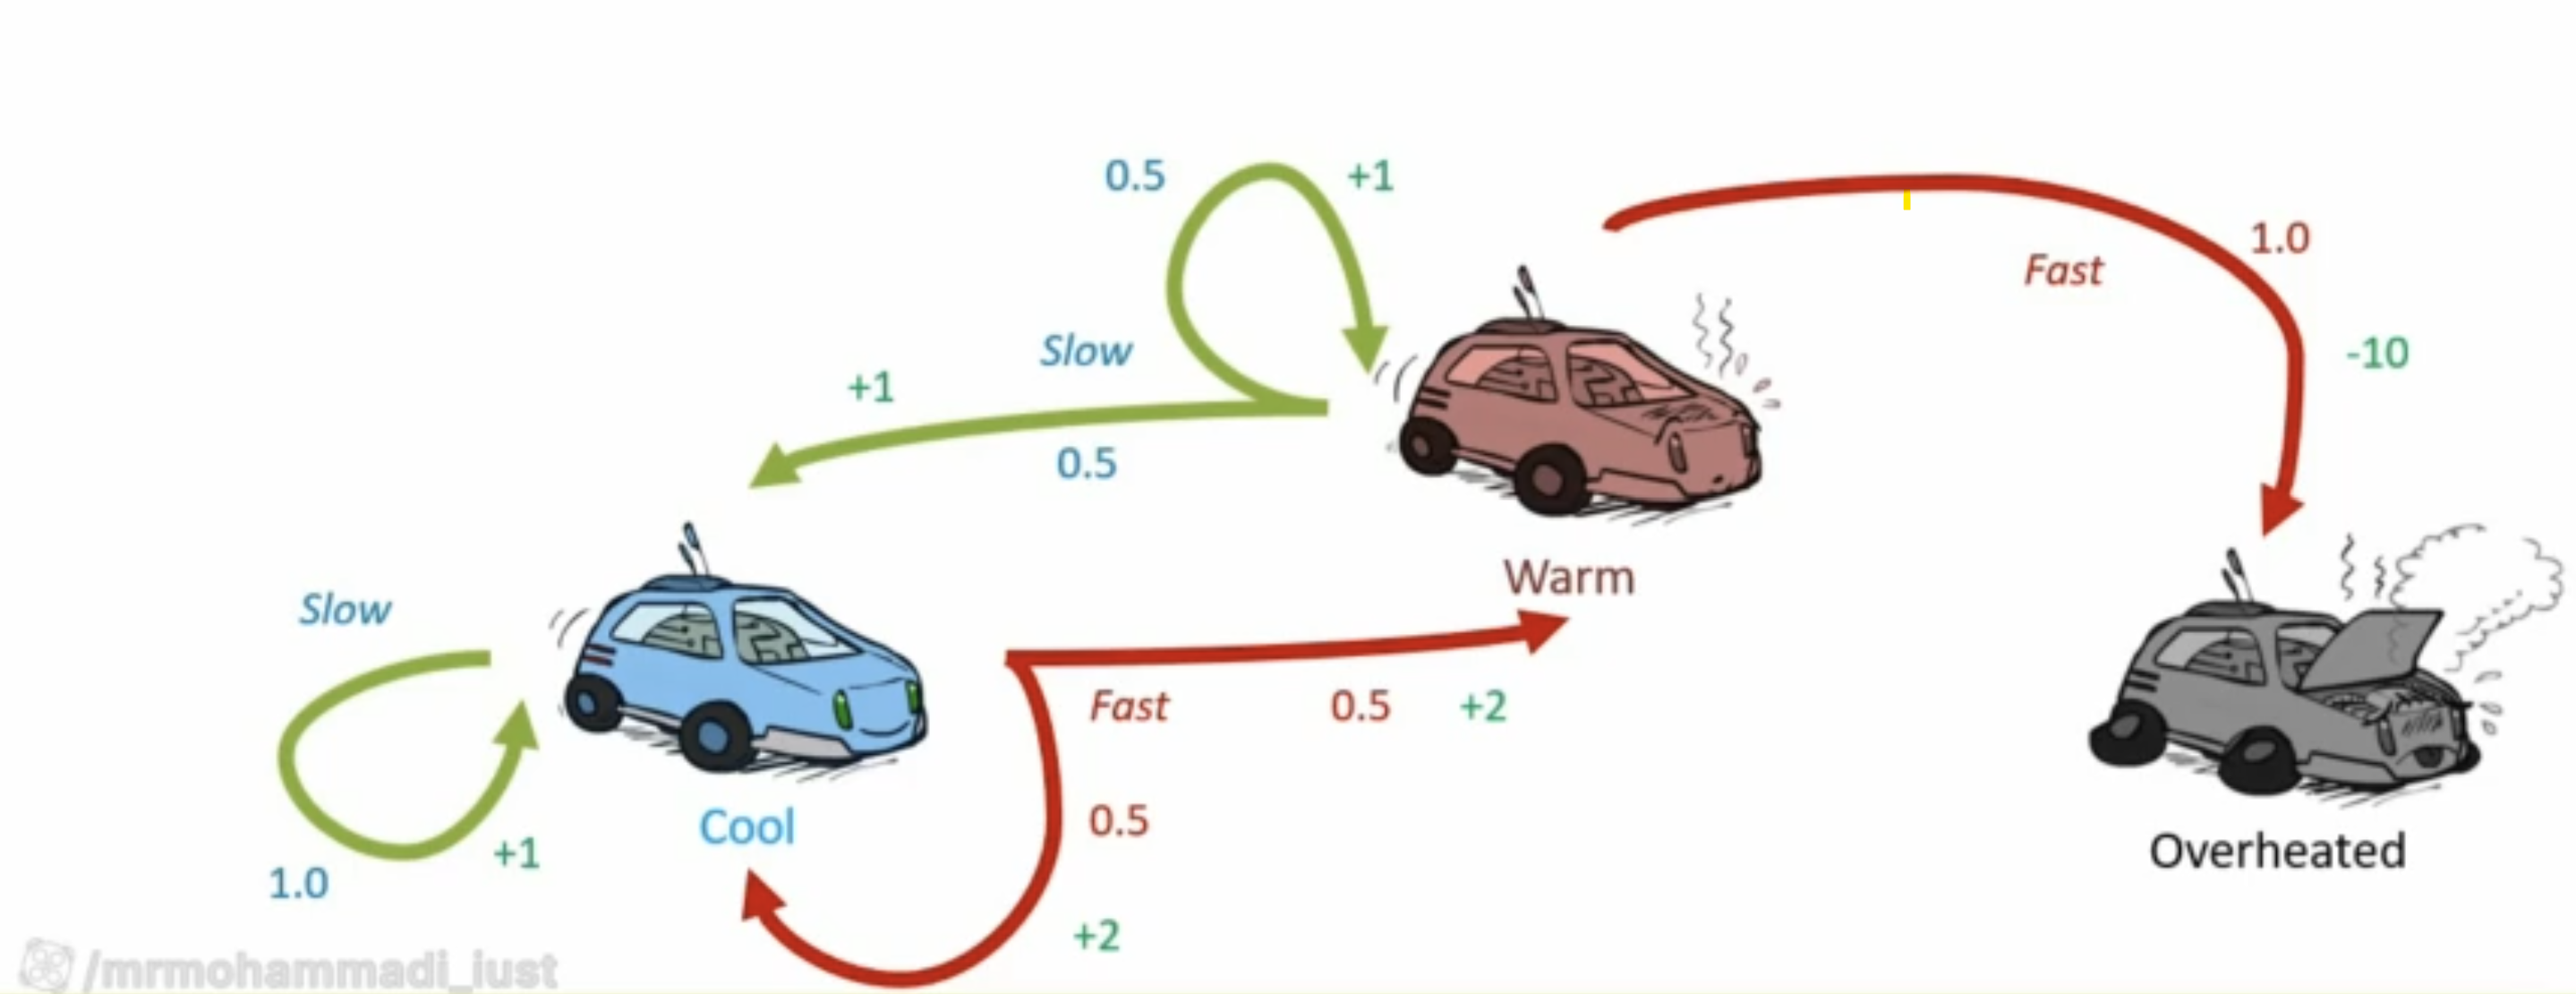
<center>Figure 2: Example's transition model, Adopted from [1]</center>
<br>

> Going faster gets double reward.

If we want to search it's tree, it would be a infinite tree and our competetion does not have any end to it:

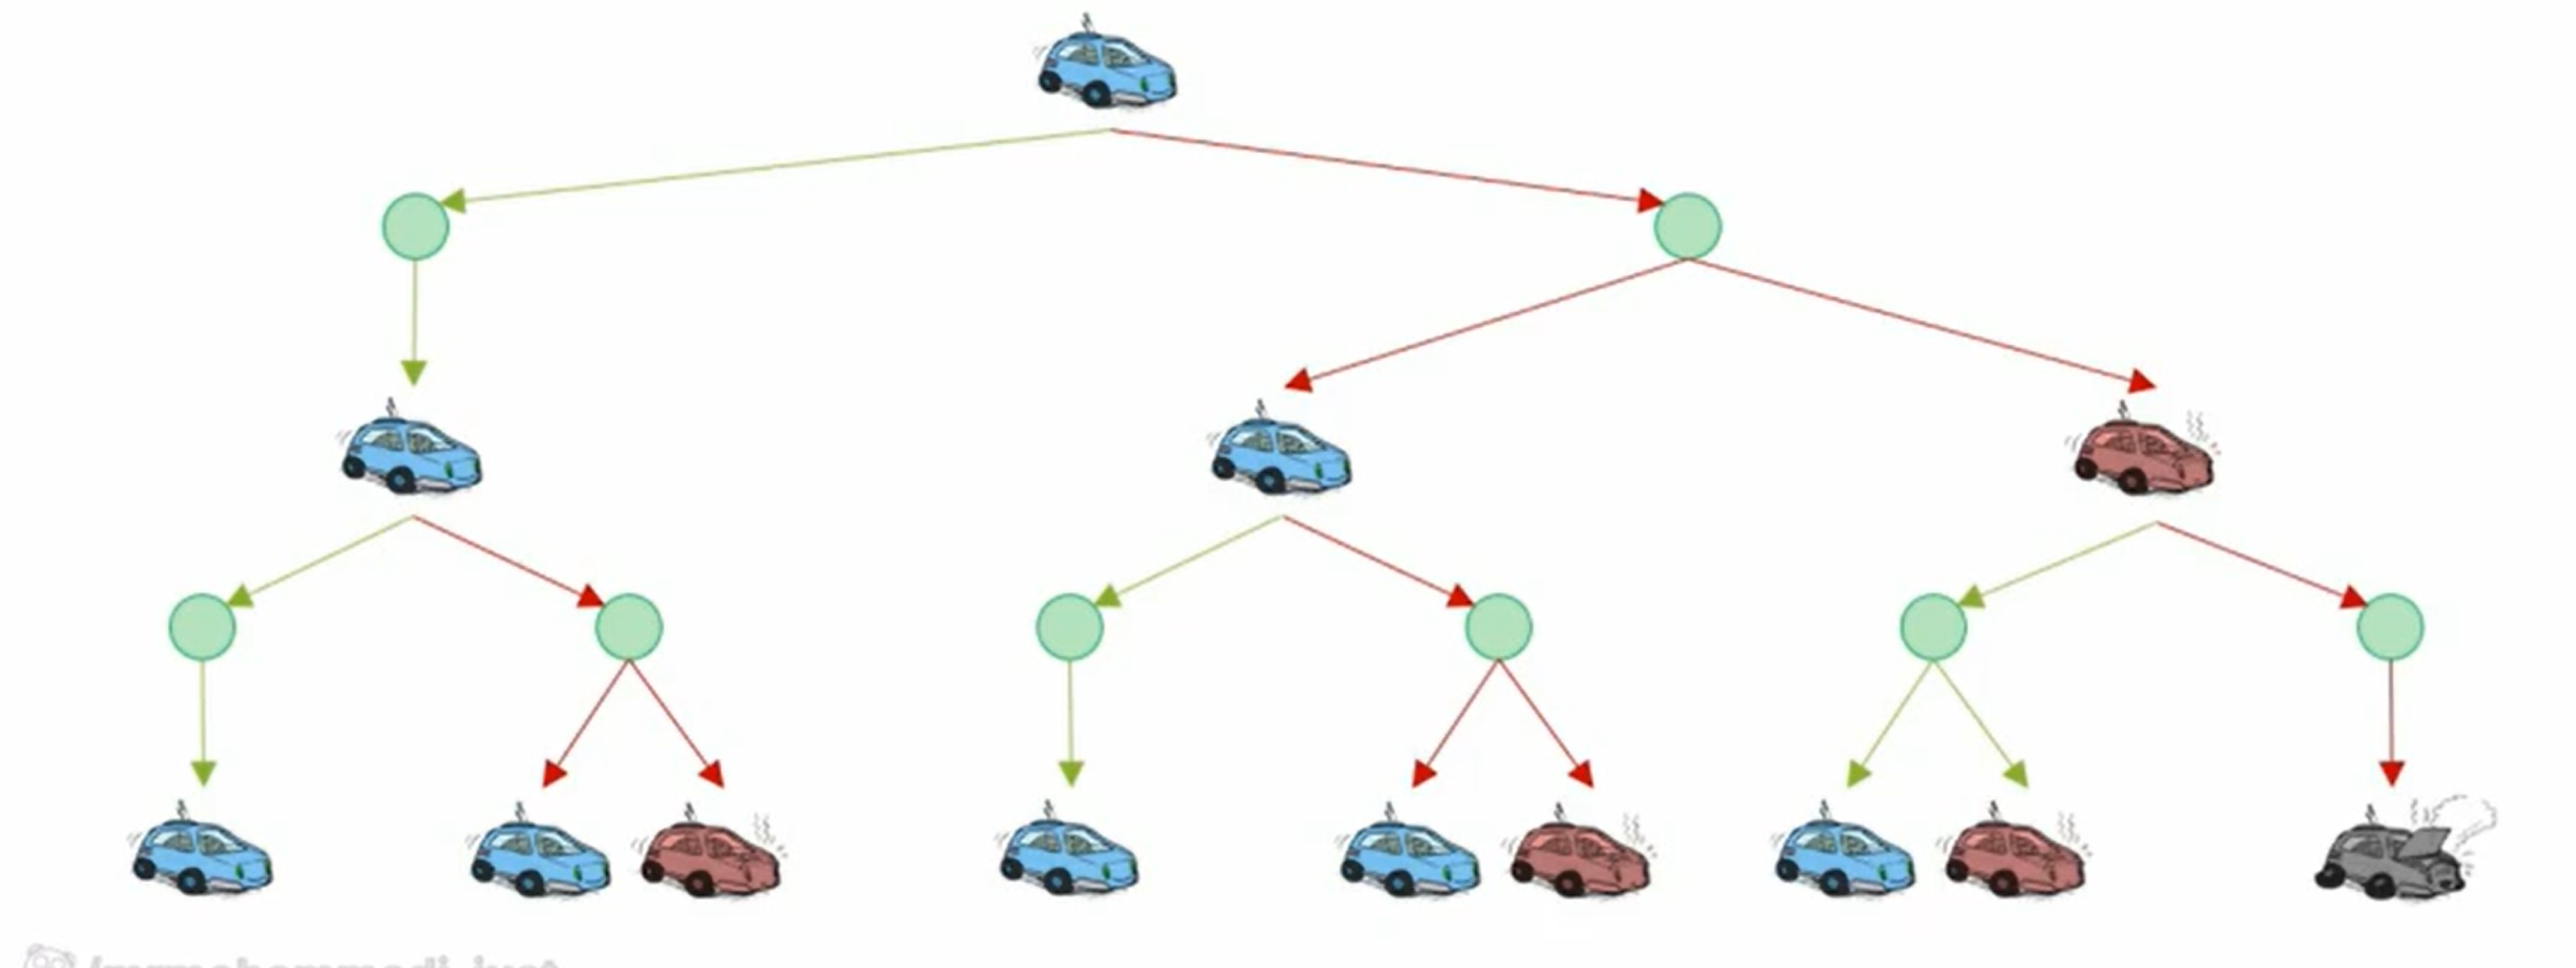
<center>Figure 3: Racing Search Tree, Adopted fromm [2]</center>
<br>

Now how we're supposed to search in a tree that is infiite or how to decide which action to do at a moment?

### MDP Search Trees:

+ Each MDP state projects an expectimax-like search tree:

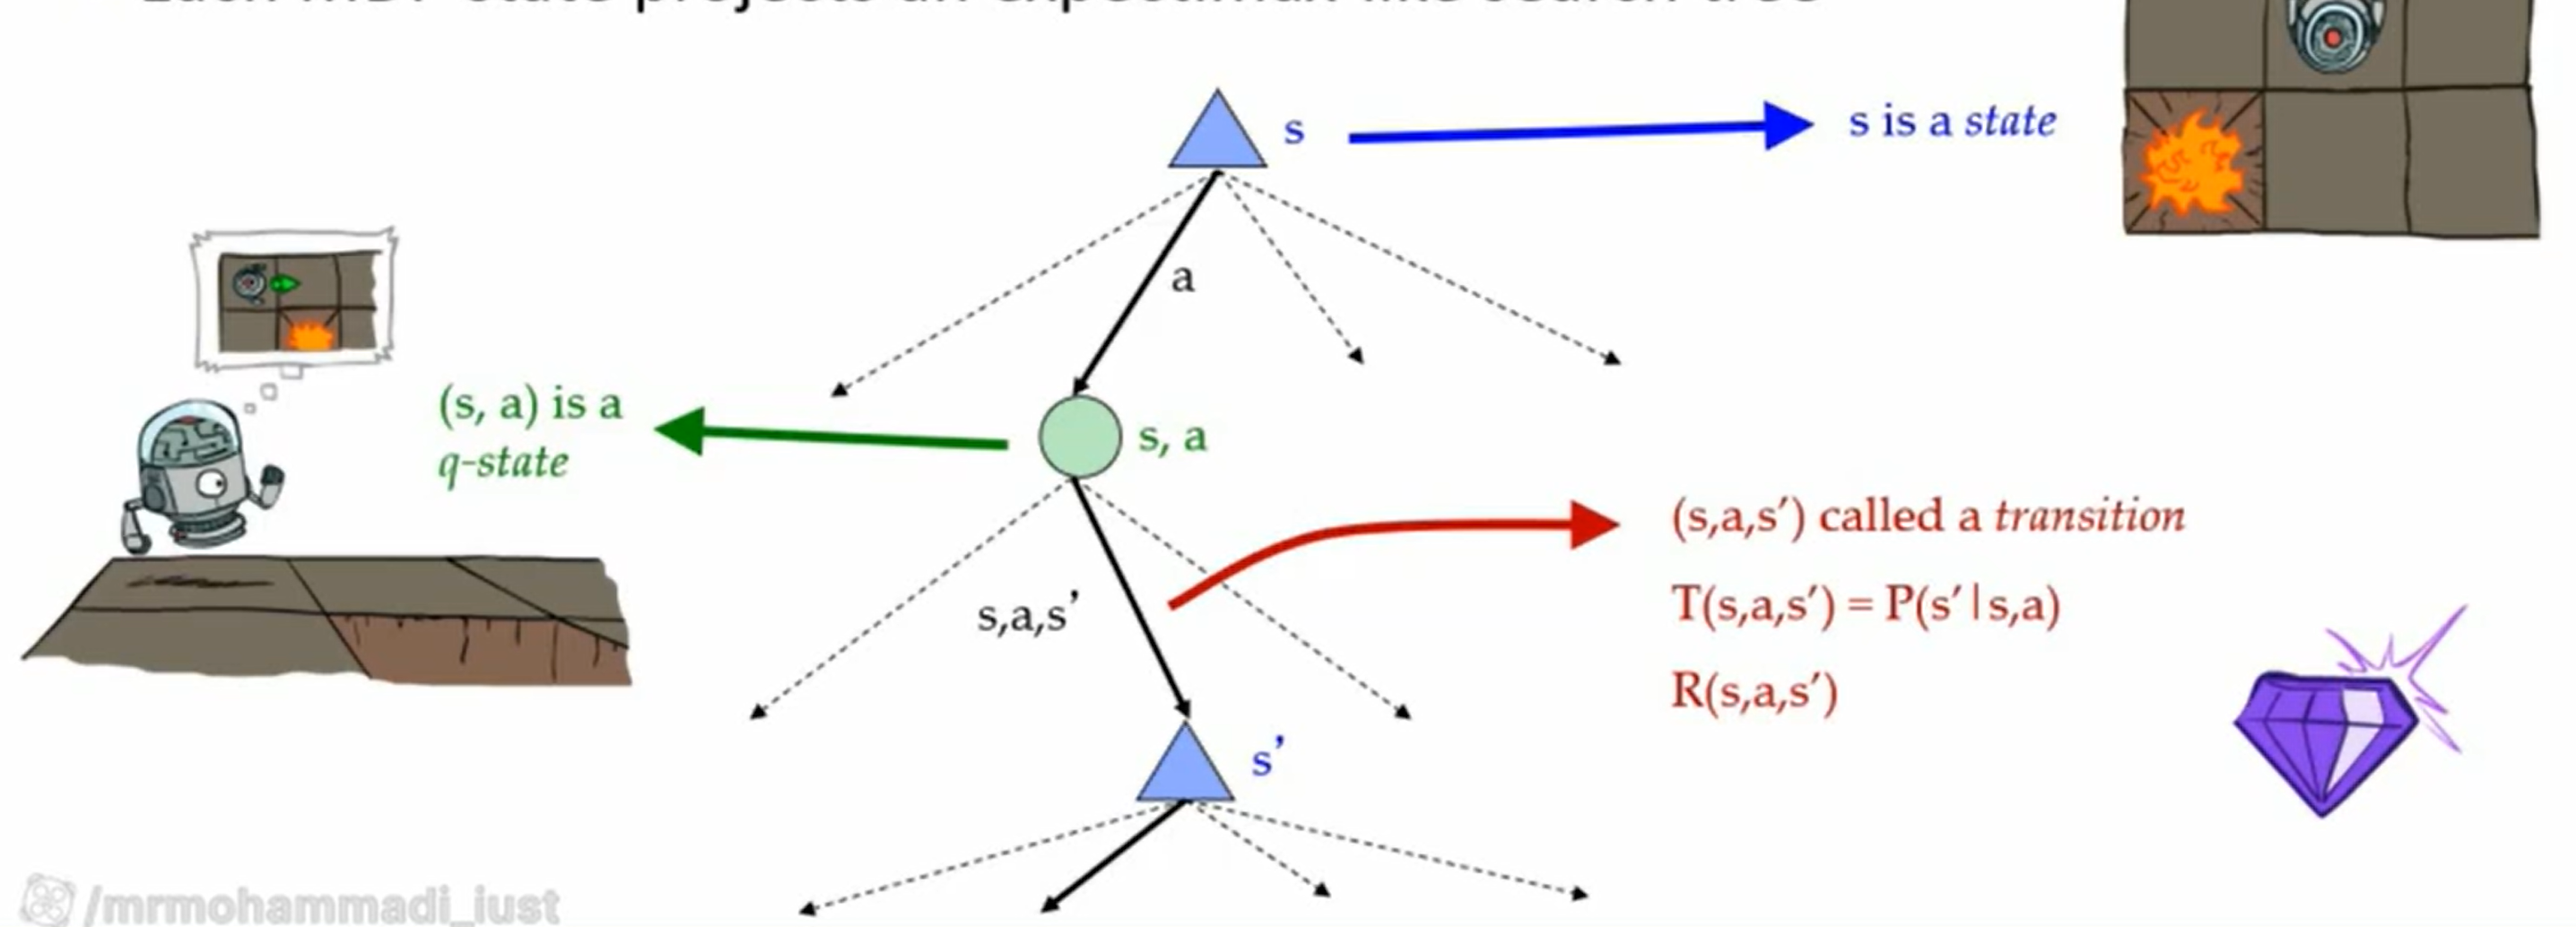
<center>Figure 4: MDP search tree, Adopted from [2]</center>
<br>

Now what should we decide?

In MDP we have sequence of rewards, not just a reward, and we should come and see which one of these sequences are better.

**Utilities of Sequences**:<br>
We said that we have sequences of rewards, now we quantify the value of each sequence with **utility** and then decide on the sequence to choose. For calculating the better sequence of rewards or calculating their utilities we value closer reward better than the futher ones so that in scenarios if the sum of the reward of each sequence is equal, the one reward that is more closer to the agent would value more so the sequences' utility would not get equal to each other.<br>
So the thing that is important for us in sequences are: the sum of reward, and getting to reward sooner, for impolementing this we use a concept called **discounting**:

+ It's reasonable to maximize the sum of rewards.
+ It's also reasonable to prefer rewards now to rewards later.
+ So the solution is: values of rewards decay exponentially.

**Why discount**:
+ Reward now is better than later
+ Can also think of it as a 1-gamma chance of ending the process at every step
+ Helps our algorithm converge


So **utility** equals to:
$$U = r_0 + \gamma r_1 + \gamma^2 r_2 + ....$$

<br>

**What if the game lasts forever? Do we get infinite rewards?**<br>

solutions:
+ Finite horizon: (similar to depth-limited search)
+ Terminate episodes after a fixed T steps (e.g. life)
+ Gives nonstationary policies ($\pi$ depends on time left)

> Discounting with $\gamma$ solves the problem of finite reward streams!

Geometric series: $1 + \gamma + \gamma^2 + ... = \frac{1}{1 - \gamma}$<br>
And assume rewards bounded by $R_{max}$<br>
Then $r_0 + \gamma r_1 + \gamma^2 r_2 + ...$ is bounded by $\frac{R_{max}}{1- \gamma}$

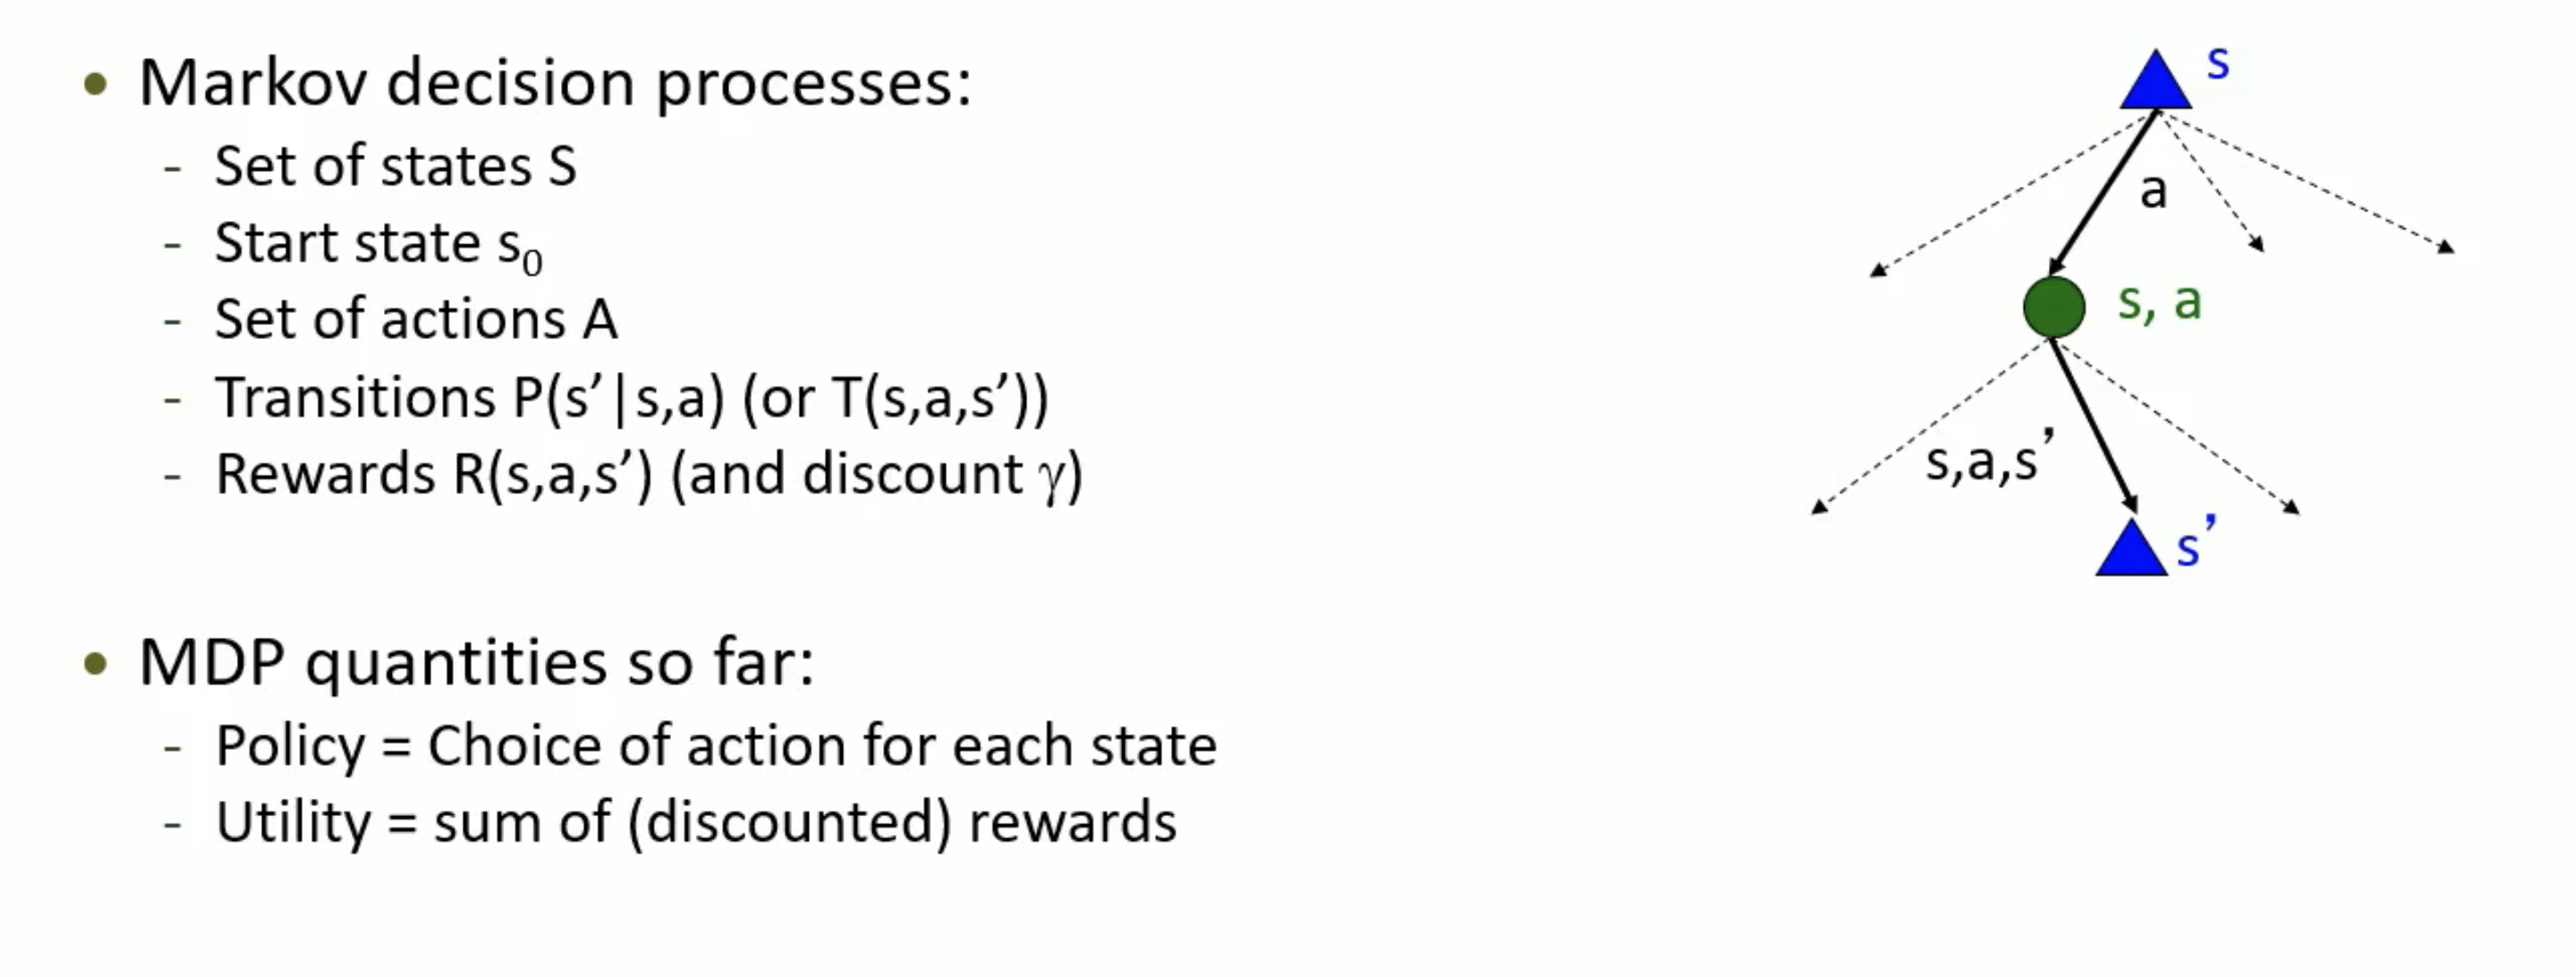
<center>Figure 4: Recap, Defining MDPs, Adopted from [2]</center>
<br>

##### Optimal Quantities

+ The value(utility) of a state *s*:
    + $V^*(s) = $ expected utility starting in *s* and acting optimally

+ The value(utility) of a q-state(s, a):
    + $Q^*(s, a) = $ expected utility starting out having taken action *a* from state *s* and (thereafter) acting optimally.

> In each state the value of $V^*$ is the maximum of the $Q$ in that state.

+ The optimal policy: 
    + $\pi^* = $ optimal action from state $s$

#### The Bellman Equations

**Value of States**:

+ Recursive definition of value:

    $$V^*(s) = \max_{a} Q^*(s, a)$$

    $$Q^*(s, a) = \sum_{s'} T(s, a, s')[R(s, a, s') + \gamma V^*(s')]$$

> Each state can contain bunch of actions.

Now we combine the two equation above and make it recursive based on $V^*$:

$$V^*(s) = \max_{a} \sum_{s'} T(s, a, s')[R(s, a, s') + \gamma V^*(s')]$$

#### Time-Limited Values

Our calculations time is limited and we cannot calculate the infinite of the sigmas and reach to the $V^*$.

+ We define $V_k(s)$ to the optimal value of $s$ if the game ends in $k$ more time steps. It's an estimation of $V^*$. And we do this by iterating and increase the value of $k$ in each iteration and stop when we recognized no bold change in the value of states from it's previous iteration.

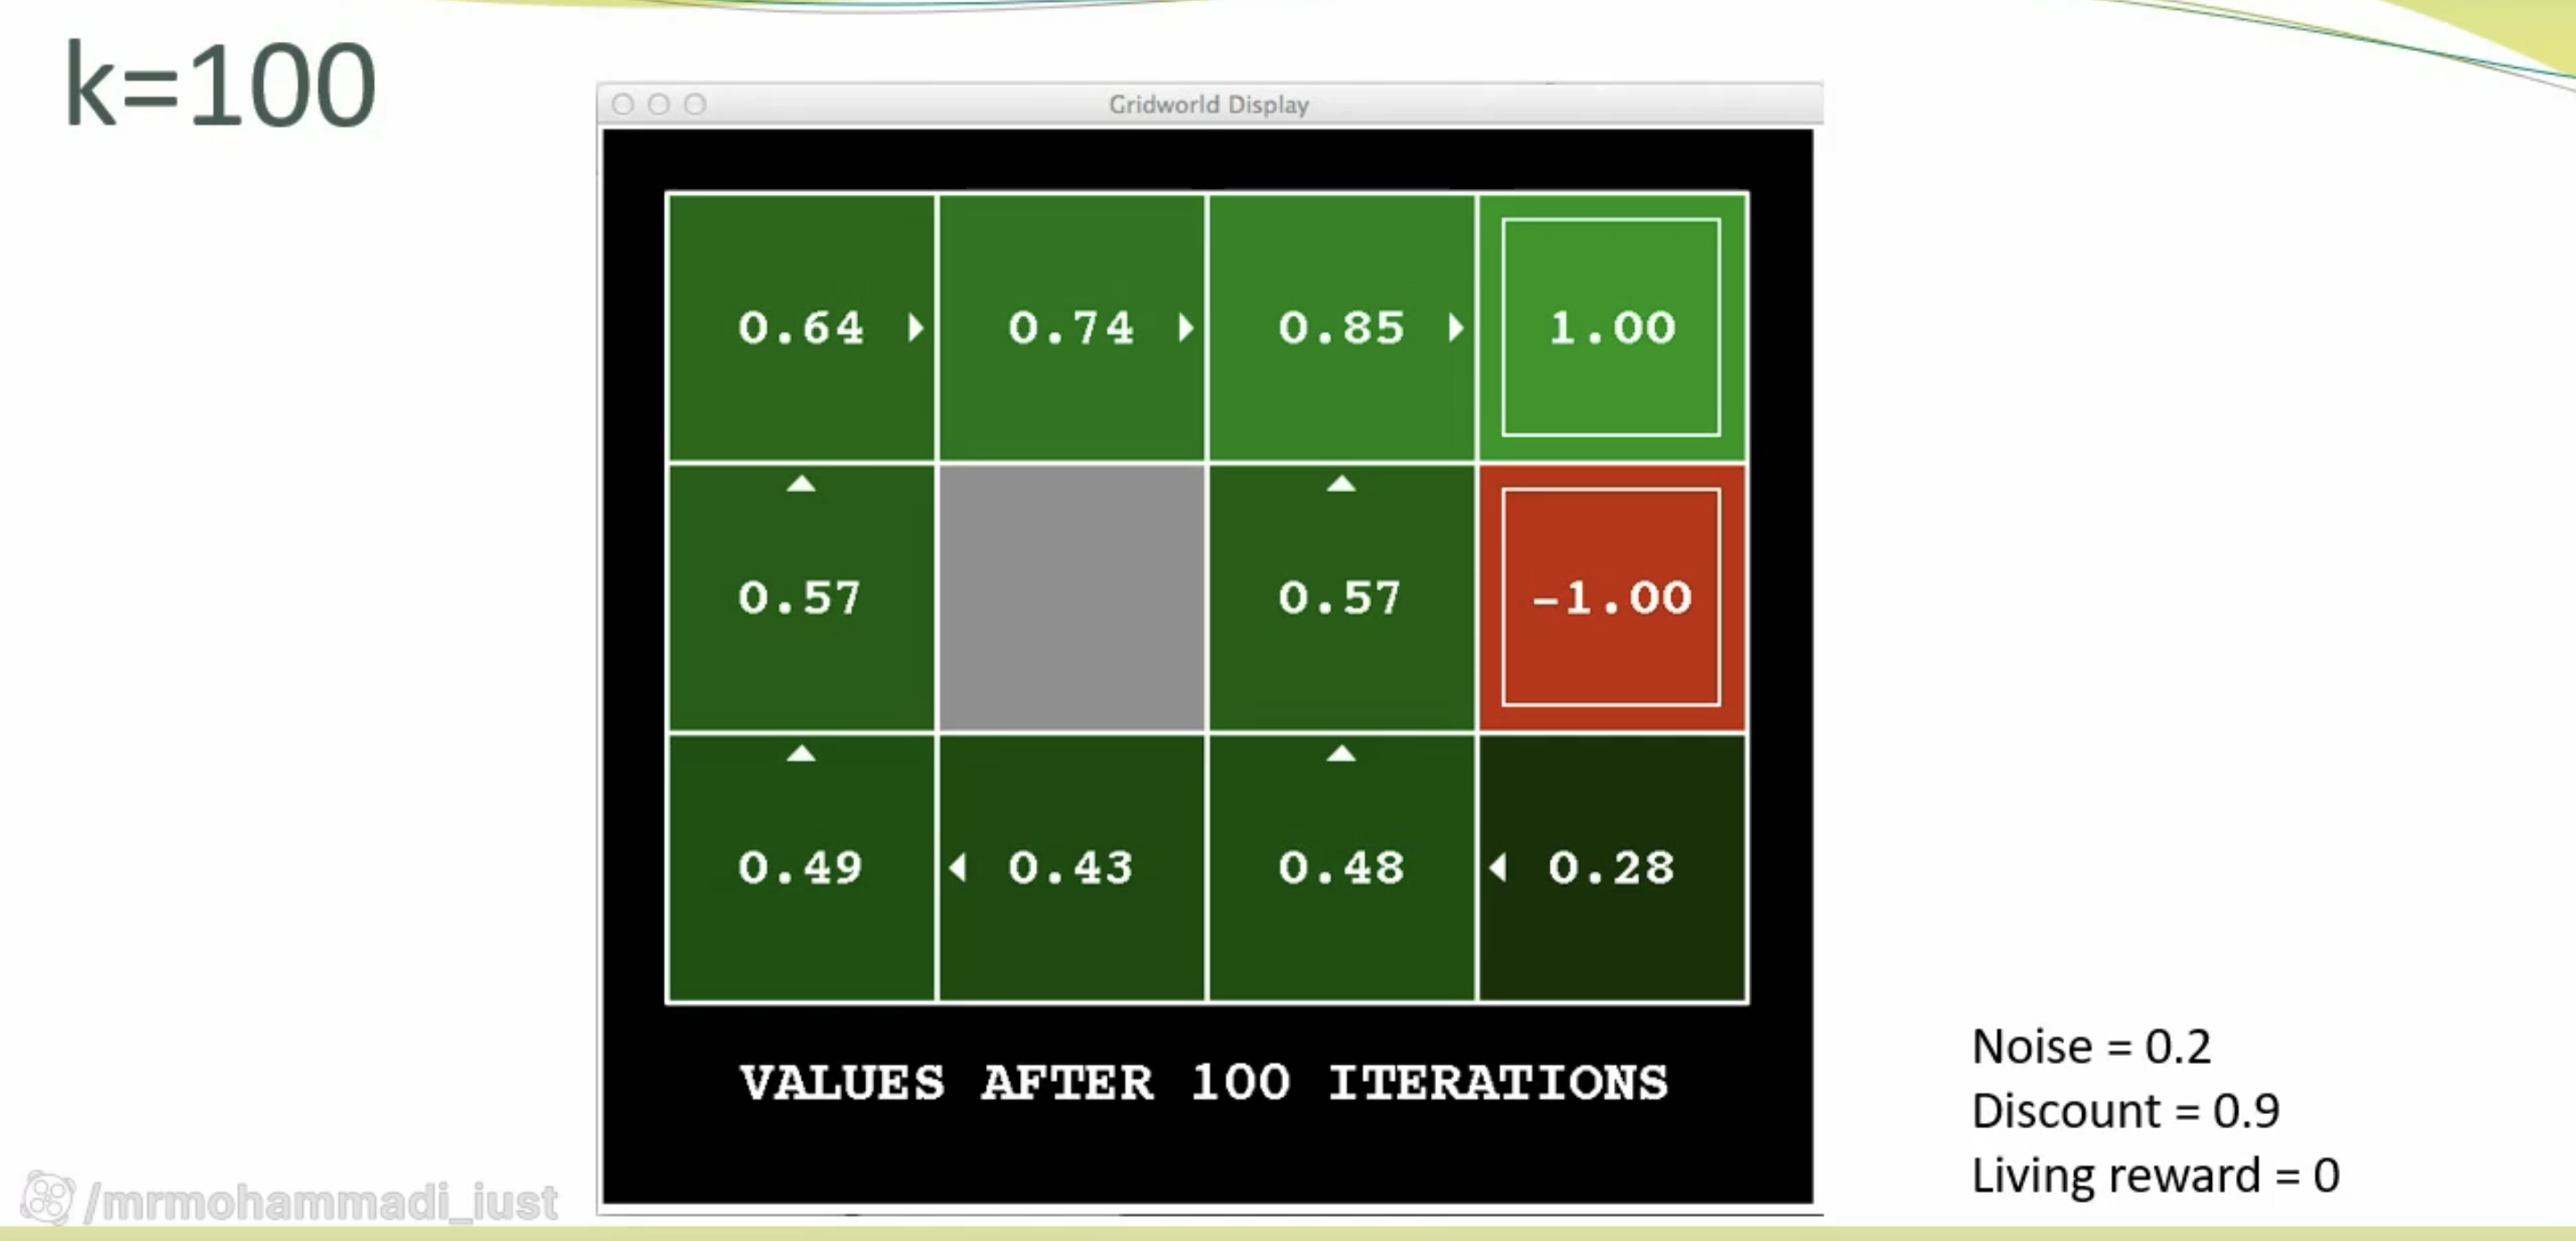
<center>Figure 5: Example, Adotped from [2]</center>

These above methods are called **Value Iteration** and it's purpose is to make the values converge. And we have a **Policy Iteration** that does not wait till the convergence of our values, it says that after 3-4 iterations, our decisions are obvious and we select those decisions and because of that the pace of the policy iteration is better than the value iteration. **Value Iteration** looks for the optimal values, and **Policy Iteration** looks for the optimal/correct actions.

> The fact that how much does it takes to converge in value iteration is also dependant on the number of states.

#### Value Iteration:

+ Start with $V_0(s) = 0$: no time steps left means an expected reward sum of zero.
+ Given vector of $V_k(s)$ values, do one ply of expectimax from each state:

    $$V_{k+1}(s) \leftarrow \max_{a} \sum_{s'} T(s, a, s')[R(s, a, s') + \gamma V_k(s')]$$

+ Repeat until convergence, which yields $V^*$
+ Will converge to unique optimal values.

> But the thing is this approach can cost so much based on how many iteration we should take to converge, and policy may converge long before values do

+ Complexity of each iteration: $O(S^2A)$

> So as you can see if number of states increases the complexity of vallue iterationo increases quadratic and thus we have to have more iteration for convergence.

> The thing is important for us in value iteration is to find the value of states and then find the optimal sequence, So finding the right sequence and actions are important for us. And the thing is our optimal policy or sequence would appear much more faster and sooner than state's value's convergence. So the thing we're trying to say is that policy would converge faster than value.

> Bellman equations **characterize** the optimal values.

**Value Iteration**:

+ Init:
    $$\forall s: V(s) = 0$$
+ Iterate:
    $$\forall s: V_{new}(s) = \max_{a} \sum_{s'} T(s, a, a')[R(s, a, s') + \gamma V(s')]$$
    $$V = V_{new}$$

Note: Can even directly assign to $V(s)$, which will not compute the sequence of $V_k$ but will still converge to $V^*$.

#### Policy Extraction:

We have set the utilities of each state, the question here is which action should we choose? 

+ Let's imagine we have the optimal values $V^*(s)$.
+ How should we act?

+ We need to do mini-expectimax (one step):

    $$\pi^* = \argmax_{a} \sum_{s'} T(s, a, s')[R(s, a, s') + \gamma V^*(s')]$$

This is called **policy extraction**, since it gets the policy implied by the values.

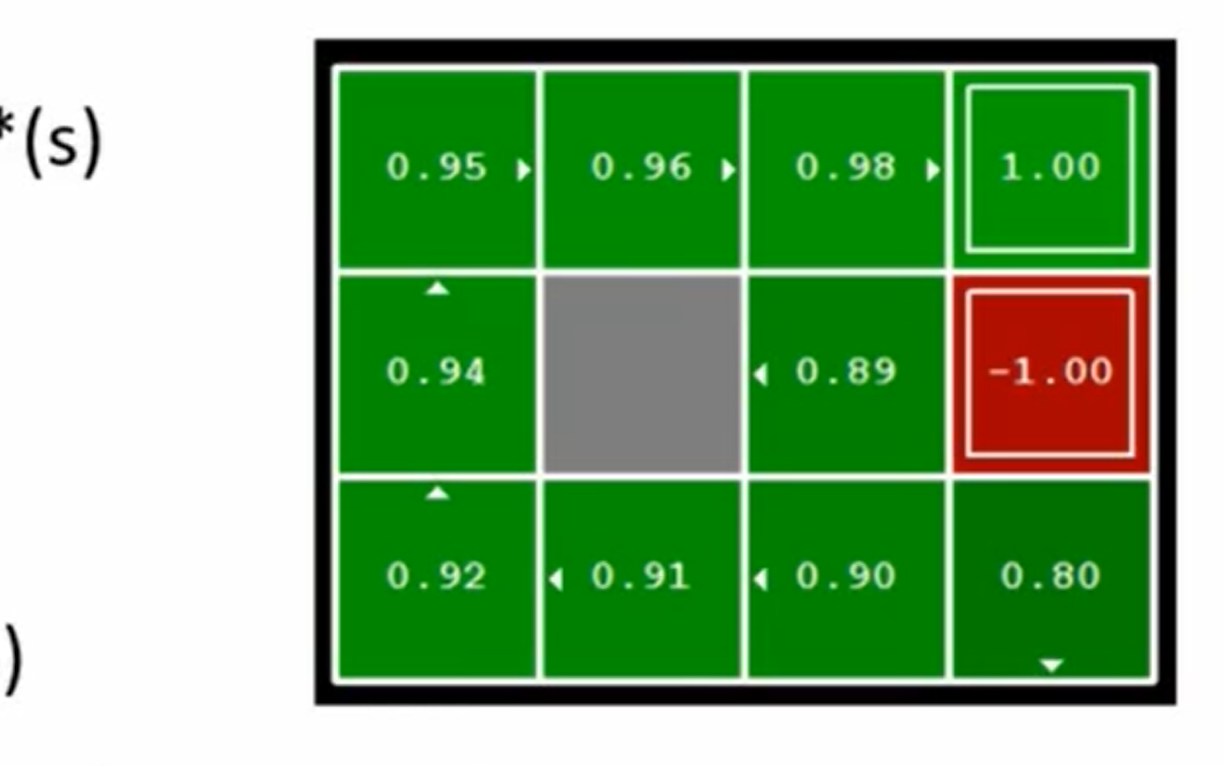
<center>Figure 6: Adopted from [2]</center>
<br>

#### Computing Actions from Q-values:

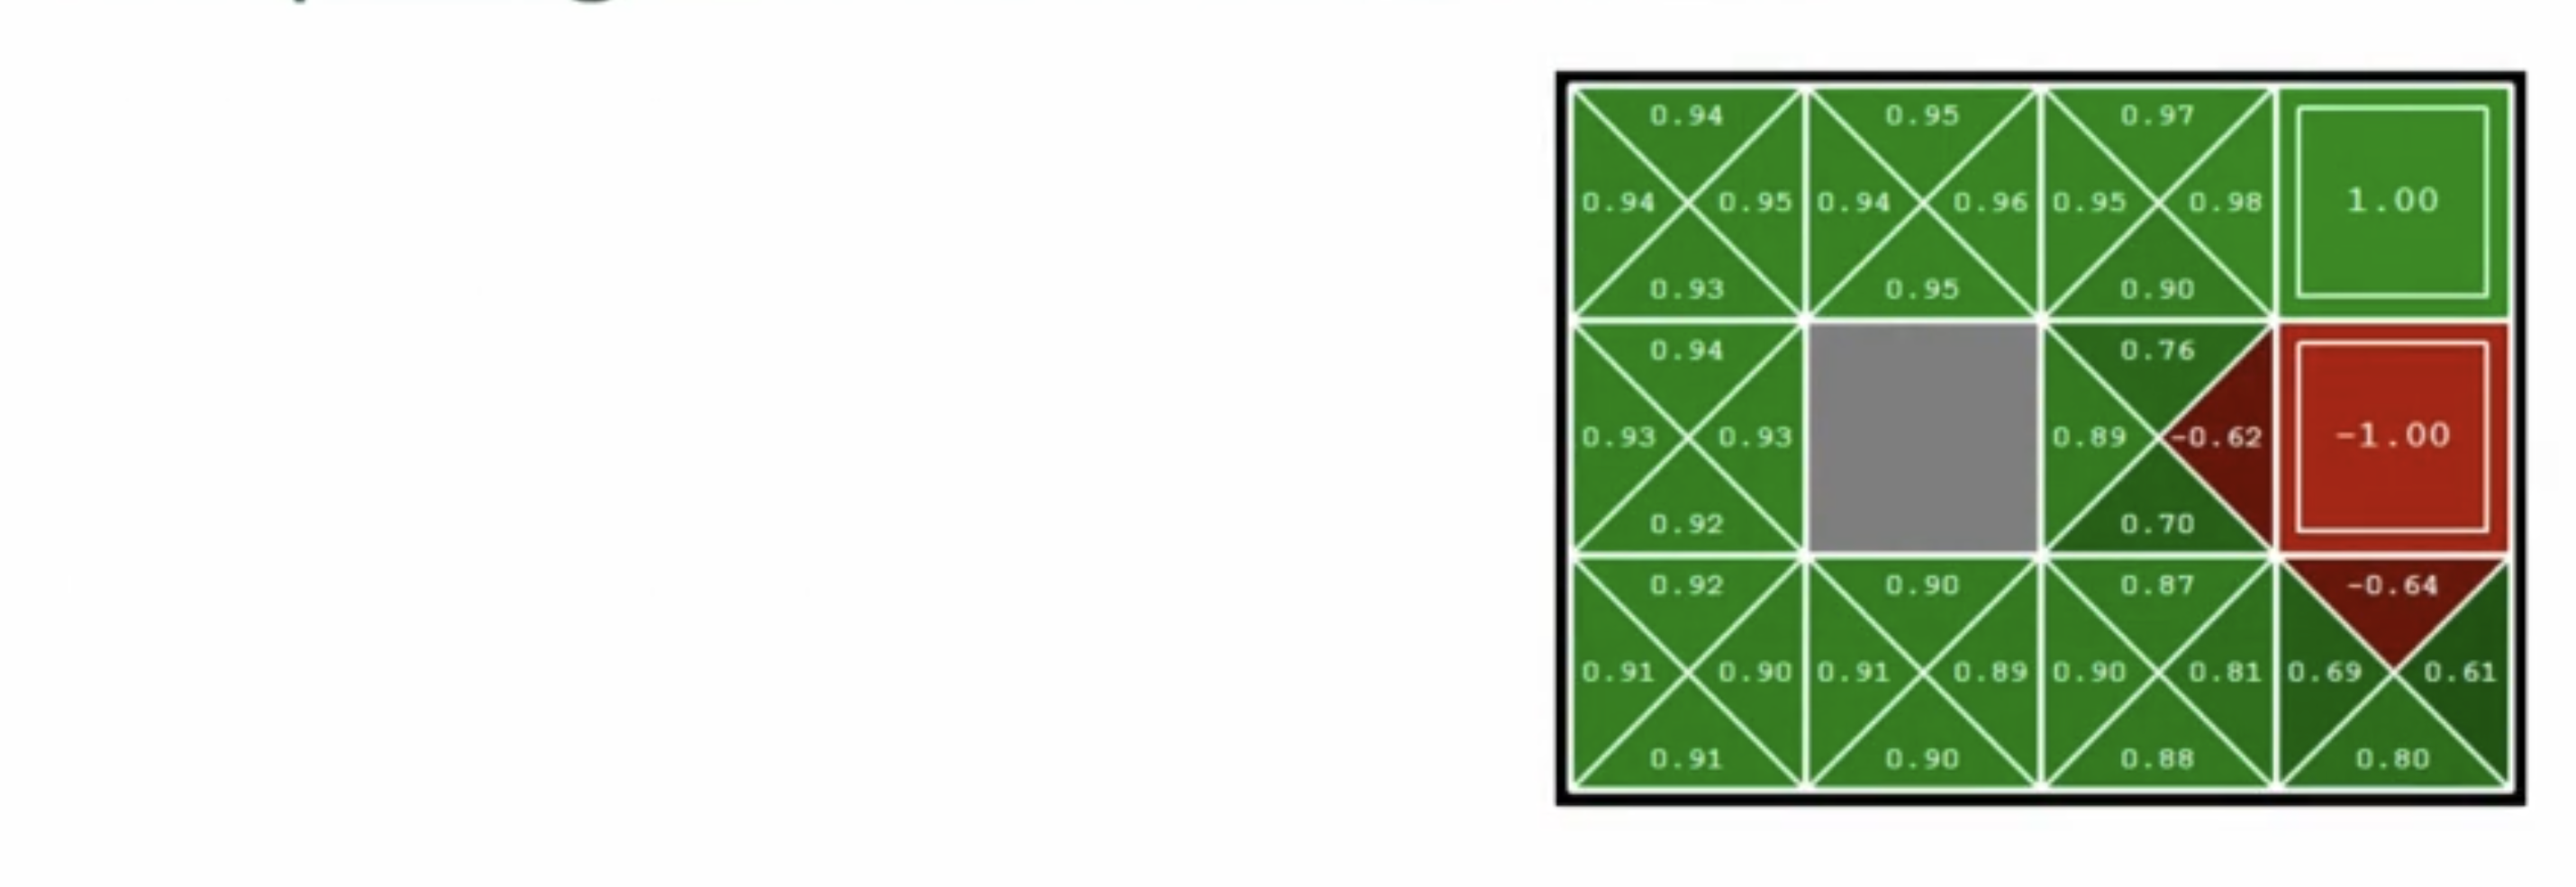
<center>Figure 7:Q values action-state, Adopted from [2]</center>
<br>

> What if we had q-values, like when we estimated values, we directly just estimate actions.

+ How should we act?

$$\pi^*(s) = \argmax_{a} Q^*(s, a)$$

+ Important lesson: actions are easier to select from q-values than values!

#### Problems with value iteration:

+ Value iteration repeats the Bellman updates.

    $$V_{k+1}(s) \leftarrow \max_{a} \sum_{s'} T(s, a, s') [R(s, a, s') + \gamma V_k(s')]$$

    + It's slow -> $O(S^2A)$ per iteration
    + The "max" at each state rarely changes.
    + The policy often converges long before the values.

> There are some methods called "Policy Methods", and they directly go for the policy function, and not first go for the value and then policy function. They are called **policy iteration** methods.

#### Policy Iteration

+ Alternative approach for optimal values:
    1. **Policy Evaluation**: calculate utilities for some **fixed policy** (not optimal utilities!) until convergence.
    2. **Policy Improvement**: update policy using one-step look-ahead with resulting converged (but not optimal) utilities as future values.
    3. Repeat these steps until convergence.

This is **Policy Iteration** -> It's still optimal and can converge much faster under some conditions

> The convergence means the fixed policy over multiple iteration

##### Policy Evaluation:

**Fixed Policy**:

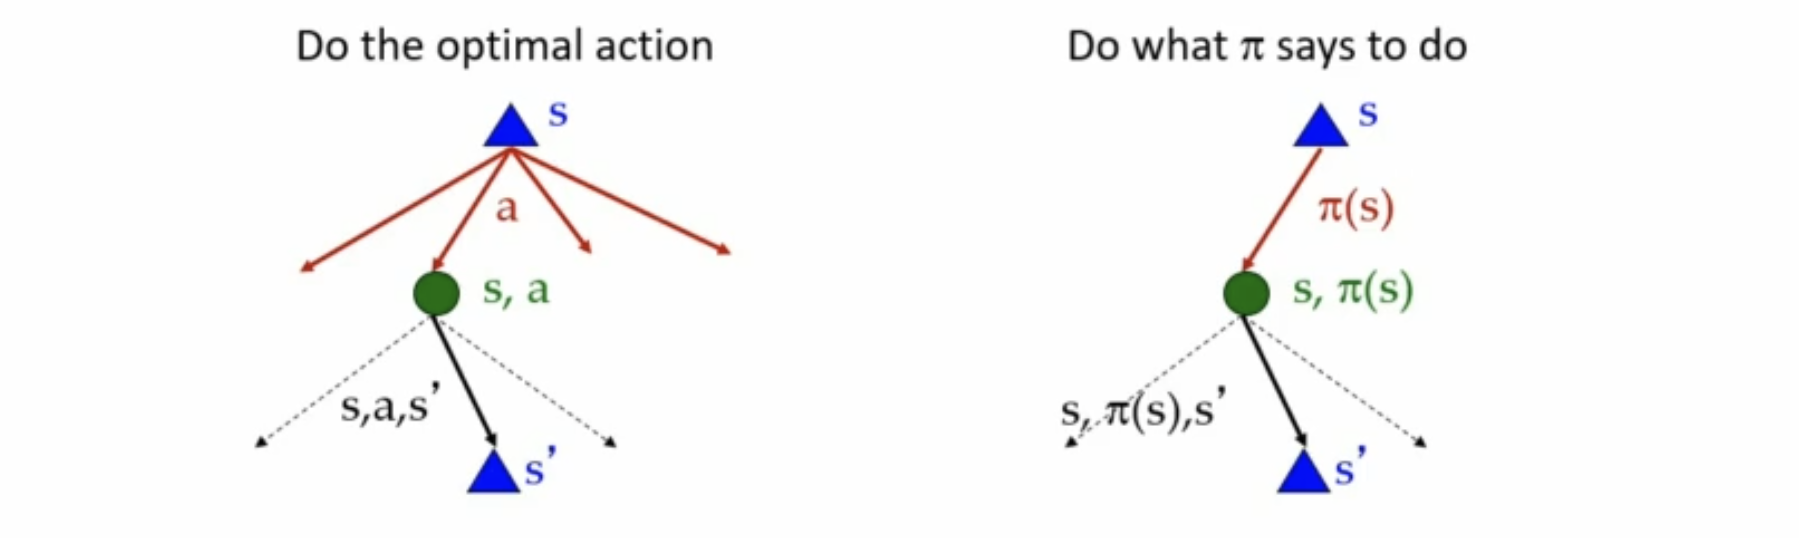
<center>Figure 8: Fixed policy example, Adopted from [2]</center>
<br>

+ Expectimax trees max over all actions to compute the optimal values
+ If we fixed some policy $\pi(s)$, then the tree would be simpler, only one action per state.

**Utilities for a fixed policy**:

Another basic operation: compute the utility of a state $s$ under a fixed (generally non-optimal) policy.

+ Define the utility of a state $s$, under a fixed policy $\pi$:
    + $V^{\pi}(s) = $ Expected total discounted reward starting in $s$ and following $\pi$.

+ Recursive relation (one-step look-ahead / Bellman equation): 

    $$V^{\pi}(s) = \sum_{s'} T(s, \pi(s), s')[R(s, \pi(s), s') + \gamma V^{\pi}(s')]$$

How do we calculate the V's for a fixed policy $\pi$?
+ Idea 1: Turn recursive Bellman equations into updates (like value iteration):
    $$V^{\pi}_0(s) = 0$$
    $$V^{\pi}_{k+1}(s) \leftarrow \sum_{s'} T(s, \pi(s), s')[R(s, \pi(s), s') + \gamma V^{\pi}_k(s')]$$
    + If we go through this idea the only gain was that our calculations became a bit easier, cause action is determined here and we only have $O(S^2)$ complexity. But we stil have iterations.

+ Idea 2: Without the "maxes", the Bellman equations are just **linear system**. It has a closed form answer.

So for summary:

+ Evaluation: For **fixed** current **policy $\pi$**, find values with policy evaluation: 
    + Iterate until values converge:
        $$V^{\pi}_{k+1}(s) \leftarrow \sum_{s'} T(s, \pi(s), s')[R(s, \pi(s), s') + \gamma V^{\pi}_k(s')]$$

+ Improvement: For **fixed** **values**, get a better policy using policy extraction.
    + One-step look-ahead:
        $$\pi_{i+1}(s) = \argmax_{a} \sum_{s'} T(s, a, s')[R(s, a, s') + \gamma V^{\pi_i}(s')]$$

### Comparison:

+ We assumed that we are in a known, stochastic environment.
+ Both value iteration and policy iteration compute the same thing (all optimal values)
+ In value iteration:
    + Every iteration updates both the values and (implicitly) the policy
    + We don't track the policy, but taking the max over actions implicitly recomputes it.
    + Runtime per iteration: $O(|S|^2 |A|)$
+ In policy iteration:
    + We do several passes that update utilities with fixed policy (each pass is fast because we consider only **one action**, not all of them.)
        + Runtime per value iteration update: $O(|S|^2) \rightarrow $ total runtime to get fixed policy values: $O(|S|^3)$
    + After policy is evaluated, a new policy is chosen (slow like a value iteration $\rightarrow O(|S|^2 |A|)$)
    + The new policy will be better (or we're done)
    + Runtime per iteration: $O(|S|^3) + O(|S|^2|A| \rightarrow )$ slower but can take much fewer iterations.

### References:

[1] [MDP1 ,IUST AI Course, Mohammadi](https://www.aparat.com/v/c68os1b)<br>
[2] [MDP Slides, CS 188, UC Berkeley](https://inst.eecs.berkeley.edu/~cs188/textbook/mdp/)<br>